In [21]:
# READMISSION RATE INVESTIGATION
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [22]:
# Load config paths
BASE_DIR = Path.cwd().parent
RAW_DATA_DIR = BASE_DIR / "data" / "raw"

PATIENTS_FILE = RAW_DATA_DIR / "patients.csv"
ADMISSIONS_FILE = RAW_DATA_DIR / "admissions.csv"
READMISSIONS_FILE = RAW_DATA_DIR / "readmissions.csv"

In [23]:
patients = pd.read_csv(PATIENTS_FILE)
admissions = pd.read_csv(ADMISSIONS_FILE)
readmissions = pd.read_csv(READMISSIONS_FILE)

# Clean column names
admissions.columns = admissions.columns.str.strip()

# Fill missing readmission reason in admissions
admissions["readmission_reason"] = (
    admissions["readmission_reason"]
    .fillna("No Readmission")
)

print("Patients:", patients.shape)
print("Admissions:", admissions.shape)
print("Readmissions:", readmissions.shape)

display(admissions.head())
display(readmissions.head())

Patients: (5000, 27)
Admissions: (8500, 22)
Readmissions: (1813, 11)


,admission_id,patient_id,admission_date,discharge_date,length_of_stay_days,admission_type,admission_source,hospital,ward,primary_diagnosis_icd,...,icu_admitted,icu_days,surgery_performed,num_procedures,attending_physician_id,discharge_disposition,total_charges_usd,insurance_paid_usd,readmitted_within_30d,readmission_reason
0,ADM-0000001,PAT-004458,2022-10-03,2022-10-12,9,Emergency,Physician Referral,MHN Cambridge,Geriatrics,N18.3,...,1,3,1,2,MD-977,Home with Home Health,32669.87,12937.91,0,No Readmission
1,ADM-0000002,PAT-001044,2023-06-24,2023-06-30,6,Urgent,Transfer,MHN Quincy,Cardiology,I10,...,0,0,0,4,MD-974,Rehab Facility,12853.73,6688.40,0,No Readmission
2,ADM-0000003,PAT-000197,2024-07-16,2024-07-19,3,Observation,Transfer,MHN Fenway,ICU,I21.9,...,0,0,1,6,MD-355,Home,15034.81,3603.22,0,No Readmission
3,ADM-0000004,PAT-001374,2020-06-23,2020-06-29,6,Emergency,Direct Admission,MHN Cambridge,Orthopedics,I63.9,...,0,0,1,1,MD-153,Skilled Nursing Facility,45572.71,10745.79,0,No Readmission
4,ADM-0000005,PAT-004116,2020-07-13,2020-07-17,4,Elective,Physician Referral,MHN Fenway,Respiratory,S72.001,...,1,3,0,2,MD-720,Home with Home Health,9312.46,8516.85,1,New condition


,readmission_id,original_admission_id,patient_id,original_discharge_date,readmission_date,days_to_readmission,readmission_type,readmission_reason,same_diagnosis,planned_readmission,avoided_if_discharged_better
0,RA-000001,ADM-0000005,PAT-004116,2020-07-17,2020-07-31,14,Urgent,New condition,1,0,0
1,RA-000002,ADM-0000006,PAT-002464,2022-09-03,2022-09-24,21,Emergency,Infection,0,1,0
2,RA-000003,ADM-0000019,PAT-001571,2022-01-15,2022-01-26,11,Emergency,New condition,0,0,1
3,RA-000004,ADM-0000020,PAT-004863,2021-03-07,2021-03-27,20,Emergency,Infection,1,0,1
4,RA-000005,ADM-0000032,PAT-003528,2020-10-12,2020-10-26,14,Emergency,Complication,1,1,1


In [24]:
# Convert date columns
admissions["admission_date"] = pd.to_datetime(
    admissions["admission_date"],
    errors="coerce"
)

admissions["discharge_date"] = pd.to_datetime(
    admissions["discharge_date"],
    errors="coerce"
)

readmissions["original_discharge_date"] = pd.to_datetime(
    readmissions["original_discharge_date"],
    errors="coerce"
)

readmissions["readmission_date"] = pd.to_datetime(
    readmissions["readmission_date"],
    errors="coerce"
)

In [25]:
# Merge patient features with admissions
patient_features = patients[
    [
        "patient_id",
        "age",
        "gender",
        "ethnicity",
        "insurance_type",
        "has_diabetes",
        "has_hypertension",
        "has_heart_disease",
        "has_copd",
        "has_ckd",
        "has_depression",
        "has_obesity",
        "has_cancer",
        "charlson_comorbidity_index",
        "num_prior_admissions",
        "num_prior_ed_visits",
        "social_support_score"
    ]
]

readmission_df = admissions.merge(
    patient_features,
    on="patient_id",
    how="left"
)

print("\nReadmission investigation dataset:")
print(readmission_df.shape)
display(readmission_df.head())


Readmission investigation dataset:
(8500, 38)


,admission_id,patient_id,admission_date,discharge_date,length_of_stay_days,admission_type,admission_source,hospital,ward,primary_diagnosis_icd,...,has_heart_disease,has_copd,has_ckd,has_depression,has_obesity,has_cancer,charlson_comorbidity_index,num_prior_admissions,num_prior_ed_visits,social_support_score
0,ADM-0000001,PAT-004458,2022-10-03,2022-10-12,9,Emergency,Physician Referral,MHN Cambridge,Geriatrics,N18.3,...,1,0,1,0,1,0,5,5,1,8
1,ADM-0000002,PAT-001044,2023-06-24,2023-06-30,6,Urgent,Transfer,MHN Quincy,Cardiology,I10,...,1,1,1,0,0,0,5,3,2,9
2,ADM-0000003,PAT-000197,2024-07-16,2024-07-19,3,Observation,Transfer,MHN Fenway,ICU,I21.9,...,1,0,0,0,0,1,4,0,0,10
3,ADM-0000004,PAT-001374,2020-06-23,2020-06-29,6,Emergency,Direct Admission,MHN Cambridge,Orthopedics,I63.9,...,1,0,0,0,1,0,3,4,0,9
4,ADM-0000005,PAT-004116,2020-07-13,2020-07-17,4,Elective,Physician Referral,MHN Fenway,Respiratory,S72.001,...,1,0,0,0,0,0,2,1,0,10


In [26]:
# Overall readmission rate
overall_readmission_rate = readmission_df["readmitted_within_30d"].mean() * 100

print(f"Overall 30-day readmission rate: {overall_readmission_rate:.2f}%")

Overall 30-day readmission rate: 21.33%


In [27]:
# Readmission rate by hospital
readmission_by_hospital = readmission_df.groupby("hospital").agg(
    total_admissions=("admission_id", "count"),
    readmissions=("readmitted_within_30d", "sum"),
    readmission_rate=("readmitted_within_30d", "mean")
).reset_index()

readmission_by_hospital["readmission_rate"] = (
    readmission_by_hospital["readmission_rate"] * 100
)

display(readmission_by_hospital)

,hospital,total_admissions,readmissions,readmission_rate
0,MHN Boston General,1139,233,20.456541
1,MHN Cambridge,1068,227,21.254682
2,MHN Dorchester,1070,229,21.401869
3,MHN Fenway,1083,203,18.744229
4,MHN Jamaica Plain,1039,216,20.789220
5,MHN Quincy,1063,235,22.107244
6,MHN Roxbury Community,1029,230,22.351798
7,MHN South Shore,1009,240,23.785927


In [28]:
# Readmission rate by ward
readmission_by_ward = readmission_df.groupby("ward").agg(
    total_admissions=("admission_id", "count"),
    readmissions=("readmitted_within_30d", "sum"),
    readmission_rate=("readmitted_within_30d", "mean")
).reset_index()

readmission_by_ward["readmission_rate"] = (
    readmission_by_ward["readmission_rate"] * 100
)

display(readmission_by_ward)

,ward,total_admissions,readmissions,readmission_rate
0,Cardiology,911,199,21.844127
1,Geriatrics,920,178,19.347826
2,ICU,915,204,22.295082
3,Medicine,971,234,24.098867
4,Neurology,989,219,22.143579
5,Oncology,956,206,21.548117
6,Orthopedics,872,174,19.954128
7,Respiratory,1011,212,20.969337
8,Surgery,955,187,19.581152


In [29]:
# Readmission rate by diagnosis
readmission_by_diagnosis = readmission_df.groupby("primary_diagnosis_desc").agg(
    total_admissions=("admission_id", "count"),
    readmissions=("readmitted_within_30d", "sum"),
    readmission_rate=("readmitted_within_30d", "mean")
).reset_index()

readmission_by_diagnosis["readmission_rate"] = (
    readmission_by_diagnosis["readmission_rate"] * 100
)

readmission_by_diagnosis = readmission_by_diagnosis.sort_values(
    "readmission_rate",
    ascending=False
)

display(readmission_by_diagnosis.head(20))

,primary_diagnosis_desc,total_admissions,readmissions,readmission_rate
5,Essential (primary) hypertension,407,103,25.307125
14,"Pneumonia, unspecified organism",450,108,24.000000
16,Syncope and collapse,427,98,22.950820
4,Diverticulosis of large intestine,416,95,22.836538
10,"Major depressive disorder, single episode",443,101,22.799097
13,Personal history of nicotine dependence,432,97,22.453704
9,Low back pain,433,95,21.939954
2,"Cerebral infarction, unspecified",414,90,21.739130
7,"Heart failure, unspecified",460,98,21.304348
11,"Malignant neoplasm of upper lobe, bronchus or ...",381,80,20.997375


In [30]:
# Readmission rate by discharge disposition
readmission_by_discharge = readmission_df.groupby("discharge_disposition").agg(
    total_admissions=("admission_id", "count"),
    readmissions=("readmitted_within_30d", "sum"),
    readmission_rate=("readmitted_within_30d", "mean")
).reset_index()

readmission_by_discharge["readmission_rate"] = (
    readmission_by_discharge["readmission_rate"] * 100
)

display(readmission_by_discharge)

,discharge_disposition,total_admissions,readmissions,readmission_rate
0,AMA,245,54,22.040816
1,Expired,179,41,22.905028
2,Home,3581,766,21.390673
3,Home with Home Health,2137,452,21.151146
4,Long-term Care,557,113,20.287253
5,Rehab Facility,660,140,21.212121
6,Skilled Nursing Facility,1141,247,21.647677


In [31]:
# Readmission rate by comorbidity level
readmission_df["comorbidity_level"] = pd.cut(
    readmission_df["charlson_comorbidity_index"],
    bins=[-1, 0, 2, 5, 20],
    labels=["None", "Low", "Medium", "High"]
)

readmission_by_comorbidity = readmission_df.groupby(
    "comorbidity_level",
    observed=False
).agg(
    total_admissions=("admission_id", "count"),
    readmissions=("readmitted_within_30d", "sum"),
    readmission_rate=("readmitted_within_30d", "mean")
).reset_index()

readmission_by_comorbidity["readmission_rate"] = (
    readmission_by_comorbidity["readmission_rate"] * 100
)

display(readmission_by_comorbidity)

,comorbidity_level,total_admissions,readmissions,readmission_rate
0,None,1513,249,16.457369
1,Low,3401,564,16.583358
2,Medium,3303,895,27.096579
3,High,283,105,37.102473


In [32]:
# Readmission reasons
readmission_reasons = readmissions["readmission_reason"].value_counts().reset_index()
readmission_reasons.columns = ["readmission_reason", "count"]

display(readmission_reasons)

,readmission_reason,count
0,Infection,468
1,New condition,463
2,Same condition,456
3,Complication,426


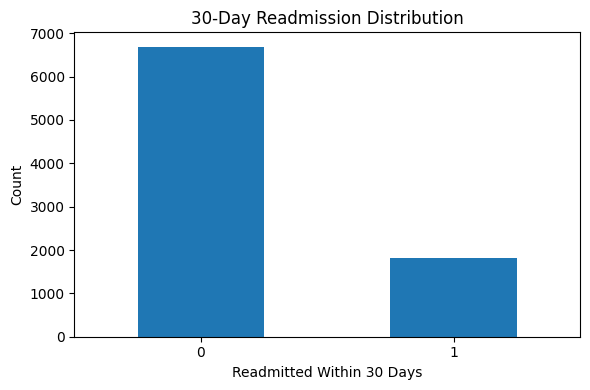

<Axes: xlabel='hospital'>

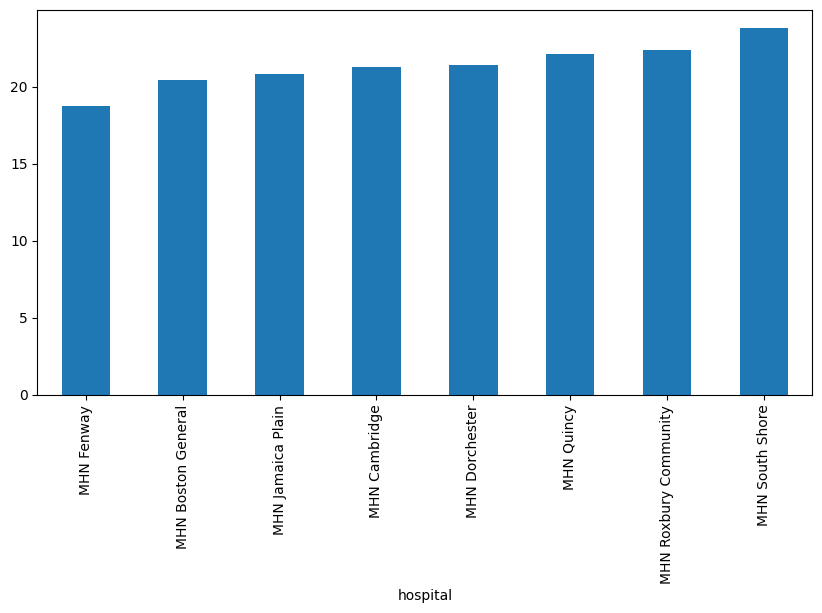

In [33]:
#  Visualisations
plt.figure(figsize=(6, 4))

readmission_df["readmitted_within_30d"].value_counts().plot(kind="bar")

plt.title("30-Day Readmission Distribution")
plt.xlabel("Readmitted Within 30 Days")
plt.ylabel("Count")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

readmission_by_hospital.sort_values("readmission_rate").plot(
    x="hospital",
    y="readmission_rate",
    kind="bar",
    legend=False,
    figsize=(10, 5)
)

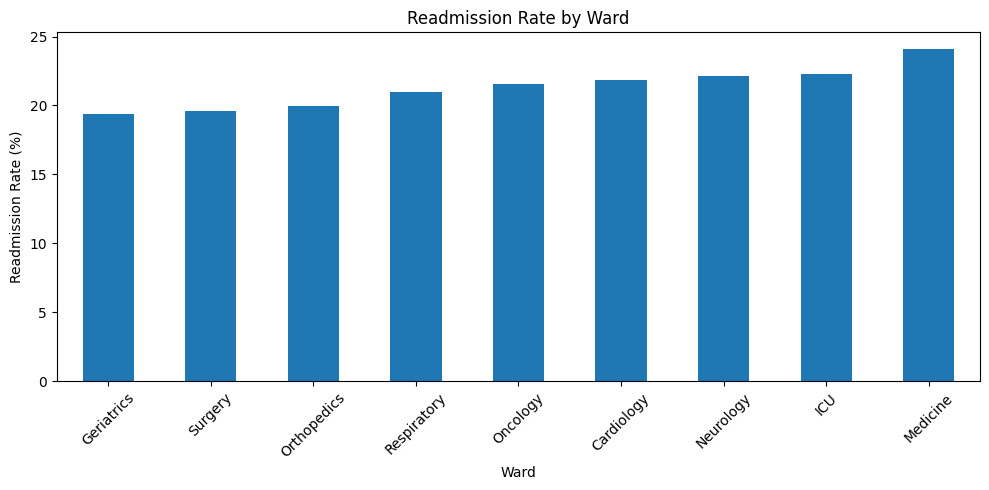

In [39]:
readmission_by_ward.sort_values("readmission_rate").plot(
    x="ward",
    y="readmission_rate",
    kind="bar",
    legend=False,
    figsize=(10, 5)
)

plt.title("Readmission Rate by Ward")
plt.xlabel("Ward")
plt.ylabel("Readmission Rate (%)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

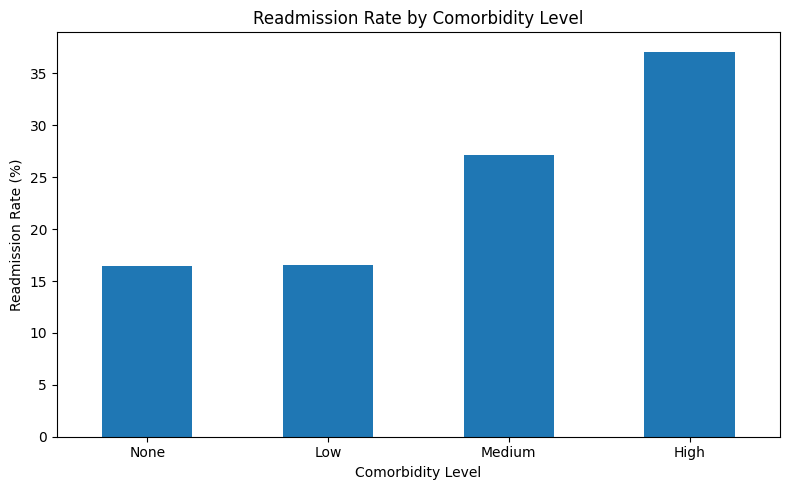

In [38]:
readmission_by_comorbidity.plot(
    x="comorbidity_level",
    y="readmission_rate",
    kind="bar",
    legend=False,
    figsize=(8, 5)
)

plt.title("Readmission Rate by Comorbidity Level")
plt.xlabel("Comorbidity Level")
plt.ylabel("Readmission Rate (%)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

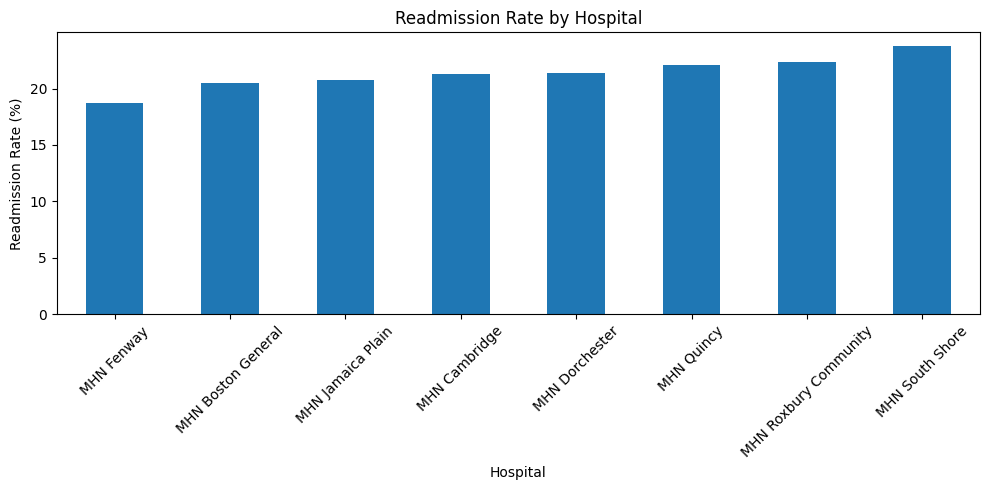

In [40]:
readmission_by_hospital.sort_values("readmission_rate").plot(
    x="hospital",
    y="readmission_rate",
    kind="bar",
    legend=False,
    figsize=(10, 5)
)

plt.title("Readmission Rate by Hospital")
plt.xlabel("Hospital")
plt.ylabel("Readmission Rate (%)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [41]:
# Save investigation dataset
OUTPUT_FILE = BASE_DIR / "data" / "processed" / "readmission_rate_investigation.csv"
OUTPUT_FILE.parent.mkdir(parents=True, exist_ok=True)

readmission_df.to_csv(OUTPUT_FILE, index=False)

print("Saved:", OUTPUT_FILE)

Saved: c:\Users\lapto\OneDrive\Predictive Healthcare\Health-Care-predictive-Analysis\data\processed\readmission_rate_investigation.csv
